<a href="https://colab.research.google.com/github/johnsparz/ai-bootcamp-portfolio/blob/master/wk1_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 1 — AI co-pilot loop**

(A) The AI co-pilot loop is the process of working together with AI to solve problems faster and improve results step by step.


1.   Prompt – You give the AI a clear instruction or question about what you want to do.
2.   Generate Code – The AI produces code, ideas, or solutions based on your prompt.


1.   Run Code – You test the generated code in your programming environment.
2.   Read Errors/Results – You check the output to see if the code works correctly or if there are errors.

1.   Fix/Improve – You update the prompt or modify the code to solve the issues or make it better

1.   Repeat – You continue the cycle until the solution works as expected.

This loop is useful because it helps developers learn faster, debug problems quickly, and improve productivity while still understanding the code being written.

(B) Prompt:
 “Create a machine learning project using Random Forest and Gradient Boosting on a real-world sales dataset. Include data cleaning, feature engineering, model training, evaluation metrics, and visualizations using Python.”

 This prompt worked well because it was clear and specific. Because the instructions were detailed, the AI generated a complete and organized solution that was easier to understand and improve.











**TASK 2 — Diabetes + pandas**

In [23]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset from github
df = pd.read_csv("https://raw.githubusercontent.com/johnsparz/ai-bootcamp-portfolio/4eaa7f91c4857f53ffbf7f81f2982f57b6522710/diabetes.csv")

# Display first rows
print("FIRST 5 ROWS")
print(df.head())


FIRST 5 ROWS
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [10]:
# Statistical summary
print("\nDATA DESCRIPTION")
print(df.describe())


DATA DESCRIPTION
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000

Question 1: How many patients have diabetes?

Explanation: The Outcome column uses 1 to represent patients diagnosed with diabetes.

In [12]:
diabetes_count = df[df["Outcome"] == 1].shape[0]
print("Patients with diabetes:", diabetes_count)

Patients with diabetes: 268


Question 2: What is the average glucose level?

Explanation: The average glucose level helps us understand the general blood sugar trend among all patients in the dataset.

In [13]:
average_glucose = df["Glucose"].mean()
print("Average glucose level:", average_glucose)

Average glucose level: 120.89453125


Question 3: Show only female patients above age 40

Explanation: Filtering patients above age 40 is useful because diabetes risk often increases with age.

In [14]:
female_above_40 = df[(df["Age"] > 40)]
print(female_above_40.head())

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             6      148             72             35        0  33.6   
8             2      197             70             45      543  30.5   
9             8      125             96              0        0   0.0   
12           10      139             80              0        0  27.1   
13            1      189             60             23      846  30.1   

    DiabetesPedigreeFunction  Age  Outcome  
0                      0.627   50        1  
8                      0.158   53        1  
9                      0.232   54        1  
12                     1.441   57        0  
13                     0.398   59        1  


Question 4: Group by outcome and show average BMI

Explanation: This comparison helps show whether BMI differs between diabetic and non-diabetic patients.

In [15]:
average_bmi = df.groupby("Outcome")["BMI"].mean()
print(average_bmi)

Outcome
0    30.304200
1    35.142537
Name: BMI, dtype: float64


Question 5: Drop rows with missing or zero glucose values — how many rows were removed?

Explanation: A glucose value of 0 is medically unrealistic, so removing those rows improves data quality for analysis.

In [22]:
# Count rows before cleaning
before_rows = df.shape[0]
print("Before rows:",before_rows)

# Remove rows where Glucose is 0
cleaned_df = df[df["Glucose"] != 0]

# Count rows after cleaning
after_rows = cleaned_df.shape[0]
print("After rows:",after_rows)

# Rows removed
rows_removed = before_rows - after_rows

print("Rows removed:", rows_removed)

Before rows: 768
After rows: 763
Rows removed: 5


**TASK 3 — Five chart types (Diabetes Dataset)**

Histogram

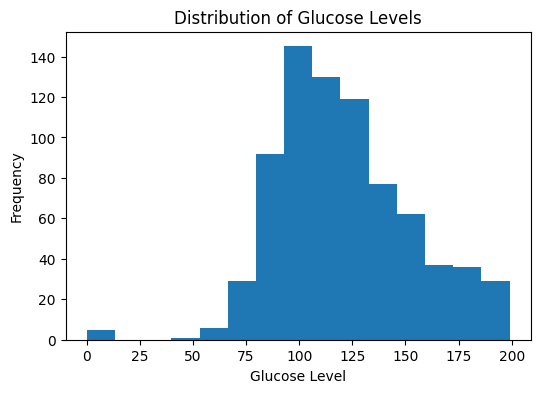

In [24]:
plt.figure(figsize=(6,4))

plt.hist(df["Glucose"], bins=15)

plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")

plt.show()

Scatter Plot

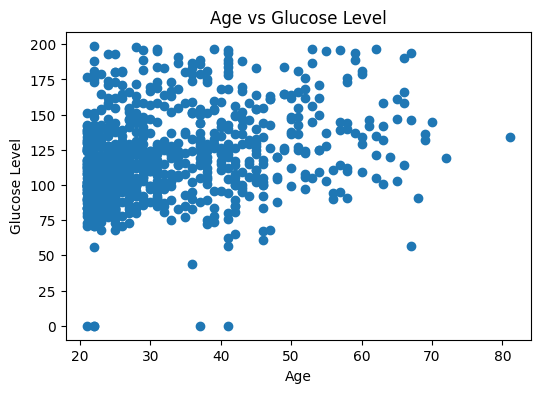

In [25]:
plt.figure(figsize=(6,4))

plt.scatter(df["Age"], df["Glucose"])

plt.title("Age vs Glucose Level")
plt.xlabel("Age")
plt.ylabel("Glucose Level")

plt.show()

Bar Chart

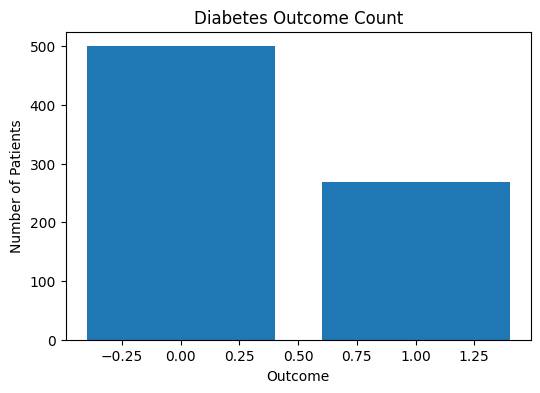

In [26]:
# Count diabetes outcomes
outcome_counts = df["Outcome"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(outcome_counts.index, outcome_counts.values)

plt.title("Diabetes Outcome Count")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

Box Plot

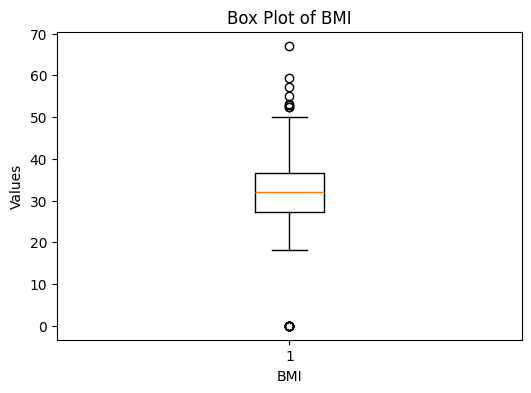

In [27]:
plt.figure(figsize=(6,4))

plt.boxplot(df["BMI"])

plt.title("Box Plot of BMI")
plt.xlabel("BMI")
plt.ylabel("Values")

plt.show()

Line Chart

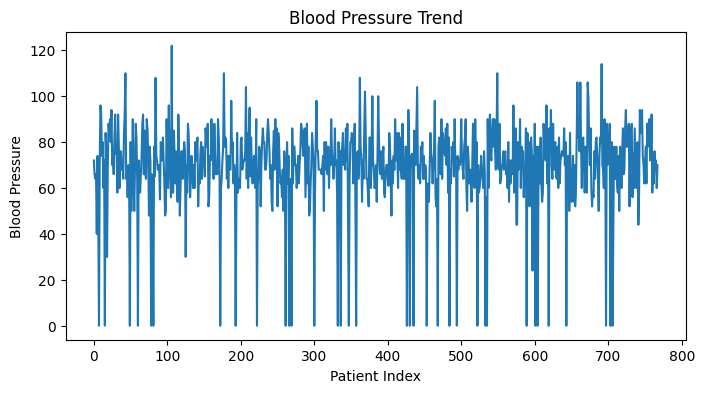

In [28]:
plt.figure(figsize=(8,4))

plt.plot(df.index, df["BloodPressure"])

plt.title("Blood Pressure Trend")
plt.xlabel("Patient Index")
plt.ylabel("Blood Pressure")

plt.show()